In [44]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [65]:
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_dir = project_root / "data"

candidate_dirs = [
    data_dir,
    data_dir / "StockExchangeData",
]

def resolve_csv(filename: str) -> Path:
    for folder in candidate_dirs:
        candidate = folder / filename
        if candidate.exists():
            return candidate
    searched = "\n".join(str(folder / filename) for folder in candidate_dirs)
    raise FileNotFoundError(f"Could not find {filename}. Searched:\n{searched}")

index_processed_path = resolve_csv("indexData.csv")
index_info_path = resolve_csv("indexInfo.csv")
index_processed_path = resolve_csv("indexProcessed.csv")

In [66]:
index_processed = pd.read_csv(index_processed_path, parse_dates=[1])
print("index_processed shape:", index_processed.shape)

index_processed shape: (104224, 9)


In [67]:
index_processed.info()

<class 'pandas.DataFrame'>
RangeIndex: 104224 entries, 0 to 104223
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Index      104224 non-null  str           
 1   Date       104224 non-null  datetime64[us]
 2   Open       104224 non-null  float64       
 3   High       104224 non-null  float64       
 4   Low        104224 non-null  float64       
 5   Close      104224 non-null  float64       
 6   Adj Close  104224 non-null  float64       
 7   Volume     104224 non-null  float64       
 8   CloseUSD   104224 non-null  float64       
dtypes: datetime64[us](1), float64(7), str(1)
memory usage: 7.2 MB


In [68]:
index_processed.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume,CloseUSD
0,HSI,1986-12-31,2568.300049,2568.300049,2568.300049,2568.300049,2568.300049,0.0,333.879006
1,HSI,1987-01-02,2540.100098,2540.100098,2540.100098,2540.100098,2540.100098,0.0,330.213013
2,HSI,1987-01-05,2552.399902,2552.399902,2552.399902,2552.399902,2552.399902,0.0,331.811987
3,HSI,1987-01-06,2583.899902,2583.899902,2583.899902,2583.899902,2583.899902,0.0,335.906987
4,HSI,1987-01-07,2607.100098,2607.100098,2607.100098,2607.100098,2607.100098,0.0,338.923013


In [69]:
index_processed['Index'].unique()

<StringArray>
[      'HSI',       'NYA',      'IXIC', '000001.SS',      'N225',      'N100',
 '399001.SZ',    'GSPTSE',      'NSEI',     'GDAXI',      'SSMI',      'TWII',
   'J203.JO']
Length: 13, dtype: str

In [70]:
index_mask = index_processed['Index'] == 'NYA'
date_mask = index_processed['Date'] >= datetime.datetime(year=2003,month=1,day=8)
nya_df = index_processed[index_mask & date_mask].set_index('Date').drop(columns=['Index', 'CloseUSD'])

# Making sure Sorted by date
nya_df = nya_df.sort_index()

nya_df.shape 

(4630, 6)

In [71]:
#Creating 2 classes (increase=1, decrease=0)
nya_df['Target'] = (nya_df['Close'].shift(-1) > nya_df['Close']).astype(int)
nya_df = nya_df.iloc[:-1]  # remove last row (no future value)

In [72]:
# Checking the proportion of up data vs down data
nya_df['Target'].value_counts(normalize=True)

Target
1    0.545906
0    0.454094
Name: proportion, dtype: float64

In [73]:
nya_df.shape

(4629, 7)

In [74]:
nya_df.head()

,Open,High,Low,Close,Adj Close,Volume,Target
Date,,,,,,,
2003-01-08,5124.189941,5124.189941,5124.189941,5124.189941,5124.189941,1.467600e+09,1
2003-01-09,5124.000000,5211.390137,5124.000000,5210.339844,5210.339844,1.560300e+09,0
2003-01-10,5210.040039,5232.169922,5165.810059,5209.799805,5209.799805,1.477200e+09,0
2003-01-13,5209.799805,5245.660156,5188.830078,5209.209961,5209.209961,1.371500e+09,1
2003-01-14,5209.209961,5233.669922,5190.970215,5233.660156,5233.660156,1.355600e+09,0


In [75]:
# Previous day's closing value - is highly correlated to MA3 and MA5 so removing it
nya_df['Last Close'] = nya_df['Close'].shift(1)

#Features for better prediction
nya_df['LowProportion'] = nya_df['Low']/nya_df['Last Close']
nya_df['HighProportion'] = nya_df['High']/nya_df['Last Close']
nya_df['DailyReturn'] = (nya_df['Close'] - nya_df['Open']) / nya_df['Open']
nya_df['VolumeReturn'] = nya_df['Volume'] * nya_df['DailyReturn']

#Average from 3 days
nya_df['MA3'] = nya_df['Adj Close'].rolling(3).mean() # maybe not this one


In [76]:
# adding more features
#nya_df['Momentum3'] = (nya_df['Close']/nya_df['Close'].shift(3) - 1).shift(1)
#nya_df['Volatility3'] = nya_df['Close'].pct_change().rolling(3).std().shift(1)
#nya_df['Range'] = ((nya_df['High']-nya_df['Low'])/nya_df['Close']).shift(1)


features = ['LowProportion','HighProportion','VolumeReturn','MA3']

#Removing Nan values
nya_df.dropna(subset=features, inplace=True)


In [77]:
nya_df_new = nya_df.copy()

#High, Low, close, opne, adj close are highly corelated to each other, Daily return and Volumn returns are highly correlated to each other and Volume is very slightly related to target
#Drop redundant/highly correlated columns
columns_to_drop = ['High', 'Low', 'Close', 'Open', 'Adj Close', 'Last Close', 'DailyReturn', 'Volume']
nya_df_new.drop(columns=columns_to_drop, inplace=True)
nya_df_new.head()

,Target,LowProportion,HighProportion,VolumeReturn,MA3
Date,,,,,
2003-01-10,0,0.991454,1.004190,-6.811342e+04,5181.443197
2003-01-13,1,0.995975,1.006883,-1.552787e+05,5209.783203
2003-01-14,0,0.996499,1.004696,6.362708e+06,5217.556641
2003-01-15,0,0.986631,1.000304,-1.648346e+07,5204.773437
2003-01-16,0,0.996568,1.006555,-1.813214e+06,5190.150065


,Target,LowProportion,HighProportion,VolumeReturn,MA3
Target,1.000,-0.033,-0.037,-0.041,-0.002
LowProportion,-0.033,1.000,0.361,0.615,0.160
HighProportion,-0.037,0.361,1.000,0.557,-0.161
VolumeReturn,-0.041,0.615,0.557,1.000,-0.012
MA3,-0.002,0.160,-0.161,-0.012,1.000


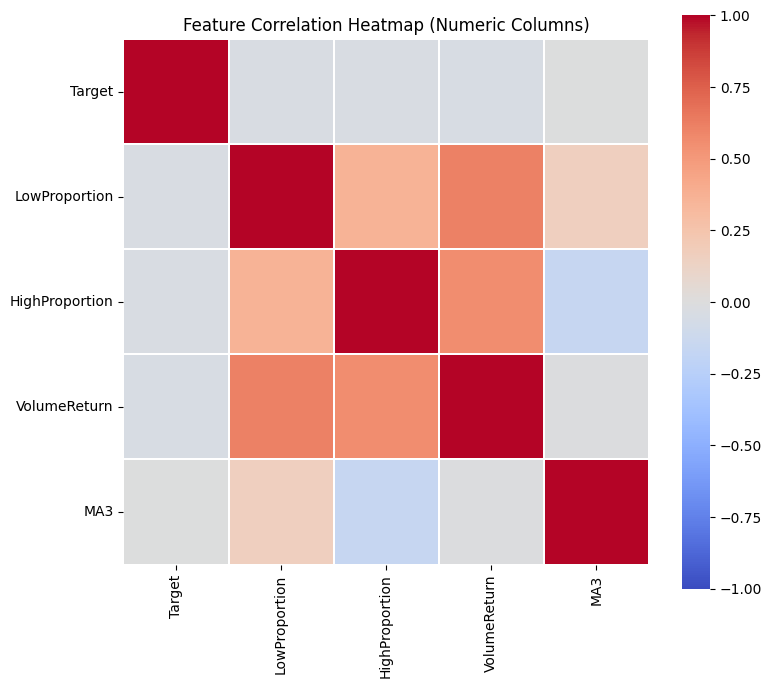

Top 10 strongest correlations (absolute):


,,correlation
LowProportion,VolumeReturn,0.615130
VolumeReturn,LowProportion,0.615130
HighProportion,VolumeReturn,0.557385
VolumeReturn,HighProportion,0.557385
LowProportion,HighProportion,0.361372
HighProportion,LowProportion,0.361372
MA3,HighProportion,-0.161117
HighProportion,MA3,-0.161117
MA3,LowProportion,0.160297
LowProportion,MA3,0.160297


In [78]:
numeric_df = nya_df_new.select_dtypes(include=[np.number]).copy()

if numeric_df.shape[1] < 2:
    print("Not enough numeric columns to compute correlation.")
else:
    corr_matrix = numeric_df.corr(numeric_only=True)
    display(corr_matrix.round(3))

    feature_count = corr_matrix.shape[0]
    fig_size = max(8, min(18, int(feature_count * 0.8)))

    plt.figure(figsize=(fig_size, fig_size))
    sns.heatmap(
        corr_matrix,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.3,
        cbar_kws={"shrink": 0.8}
    )
    plt.title("Feature Correlation Heatmap (Numeric Columns)")
    plt.tight_layout()
    plt.show()

    corr_pairs = (
        corr_matrix.where(~np.eye(corr_matrix.shape[0], dtype=bool))
        .stack()
        .sort_values(key=lambda s: s.abs(), ascending=False)
    )
    print("Top 10 strongest correlations (absolute):")
    display(corr_pairs.head(10).to_frame("correlation"))

In [79]:
#Define target
y = nya_df_new['Target']

#Define Features
X = nya_df_new.drop(columns=['Target'])

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("Features:")
print(X.head())
print("Target:")
print(y.head())

Feature shape: (4627, 4)
Target shape: (4627,)
Features:
            LowProportion  HighProportion  VolumeReturn          MA3
Date                                                                
2003-01-10       0.991454        1.004190 -6.811342e+04  5181.443197
2003-01-13       0.995975        1.006883 -1.552787e+05  5209.783203
2003-01-14       0.996499        1.004696  6.362708e+06  5217.556641
2003-01-15       0.986631        1.000304 -1.648346e+07  5204.773437
2003-01-16       0.996568        1.006555 -1.813214e+06  5190.150065
Target:
Date
2003-01-10    0
2003-01-13    1
2003-01-14    0
2003-01-15    0
2003-01-16    0
Name: Target, dtype: int64


## Time-based split

In [81]:
features = ['LowProportion','HighProportion','VolumeReturn','MA3']
X = nya_df[features]
y = nya_df['Target']

In [82]:
split_date = '2018-01-01'

X_train = X[X.index < split_date]
X_test  = X[X.index >= split_date]
y_train = y[y.index < split_date]
y_test  = y[y.index >= split_date]

## Logistic Regression

In [83]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train model
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

# evaluate
accuracy = lr.score(X_test_scaled, y_test)
print("Logistic Regression Accuracy:", accuracy)

Logistic Regression Accuracy: 0.5379229871645275


## Tree based Model

In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

print("Random Forest Accuracy:", rf.score(X_test, y_test))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Random Forest Accuracy: 0.5542590431738623
              precision    recall  f1-score   support

           0       0.48      0.12      0.19       379
           1       0.56      0.90      0.69       478

    accuracy                           0.55       857
   macro avg       0.52      0.51      0.44       857
weighted avg       0.53      0.55      0.47       857

ROC-AUC: 0.5136314458882105


In [85]:
import pandas as pd
feat_importance = pd.Series(rf.feature_importances_, index=X_train.columns)
print(feat_importance.sort_values(ascending=False))

LowProportion     0.277683
VolumeReturn      0.264680
MA3               0.241754
HighProportion    0.215883
dtype: float64


## Light XGBoost

In [91]:
import lightgbm as lgb
from sklearn.metrics import classification_report, roc_auc_score

# Train LightGBM
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
lgb_model.fit(X_train, y_train)

# Predictions
y_pred = lgb_model.predict(X_test)
y_prob = lgb_model.predict_proba(X_test)[:,1]

# Evaluate
print("Accuracy:", lgb_model.score(X_test, y_test))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

[LightGBM] [Info] Number of positive: 2048, number of negative: 1722
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000281 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1020
[LightGBM] [Info] Number of data points in the train set: 3770, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.543236 -> initscore=0.173377
[LightGBM] [Info] Start training from score 0.173377
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

## SVM

In [92]:
from sklearn.svm import SVC

svc = SVC(kernel='rbf', probability=True, random_state=42)
svc.fit(X_train_scaled, y_train)

y_pred_svc = svc.predict(X_test_scaled)
print("SVM Accuracy:", svc.score(X_test_scaled, y_test))

SVM Accuracy: 0.5519253208868145


In [98]:
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import accuracy_score

# Exogenous features
exog_features = ['LowProportion','HighProportion','VolumeReturn','MA3']
exog = nya_df[exog_features]

# Target
y = nya_df['Target']

# Train/Test split by date
split_date = '2018-01-01'
y_train = y[y.index < split_date]
y_test = y[y.index >= split_date]
exog_train = exog[exog.index < split_date]
exog_test = exog[exog.index >= split_date]

# Fit ARIMAX
model = sm.tsa.ARIMA(endog=y_train, exog=exog_train, order=(1,0,0)) # AR(1) model
arimax_result = model.fit()

# Forecast using integer positions
start = len(y_train)
end = len(y_train) + len(y_test) - 1
forecast = arimax_result.predict(start=start, end=end, exog=exog_test)

# Convert forecast to +1/-1 classes
forecast_class = forecast.apply(lambda x: 1 if x > 0 else -1)

# Evaluate
accuracy_arimax = accuracy_score(y_test, forecast_class)
print("ARIMAX Accuracy:", accuracy_arimax)

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


ARIMAX Accuracy: 0.5577596266044341


/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [96]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten

# Prepare sequences
SEQ_LEN = 10  # number of past days
features = exog_features
X_seq = []
y_seq = []

data = nya_df[features].values
target = nya_df['Target'].values

for i in range(SEQ_LEN, len(data)):
    X_seq.append(data[i-SEQ_LEN:i])
    y_seq.append(1 if target[i] > 0 else 0)  # TCN binary classification
X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Train/Test split
split_idx = np.where(nya_df.index >= '2018-01-01')[0][0] - SEQ_LEN
X_train_seq, X_test_seq = X_seq[:split_idx], X_seq[split_idx:]
y_train_seq, y_test_seq = y_seq[:split_idx], y_seq[split_idx:]

# Build simple TCN-like 1D Conv model
model_tcn = Sequential([
    Conv1D(filters=32, kernel_size=3, activation='relu', input_shape=(SEQ_LEN, len(features))),
    Conv1D(filters=16, kernel_size=3, activation='relu'),
    Flatten(),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # binary classification
])

model_tcn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_tcn.fit(X_train_seq, y_train_seq, epochs=20, batch_size=32, validation_split=0.1)

# Evaluate
loss, accuracy_tcn = model_tcn.evaluate(X_test_seq, y_test_seq)
print("TCN Accuracy:", accuracy_tcn)

Epoch 1/20


/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


106/106 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4973 - loss: 729578.3125 - val_accuracy: 0.4840 - val_loss: 125389.4062
Epoch 2/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 987us/step - accuracy: 0.5174 - loss: 302344.2500 - val_accuracy: 0.5133 - val_loss: 81210.3438
Epoch 3/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - accuracy: 0.5168 - loss: 197103.7031 - val_accuracy: 0.5293 - val_loss: 68014.1406
Epoch 4/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5024 - loss: 143689.8906 - val_accuracy: 0.5372 - val_loss: 43916.4141
Epoch 5/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5157 - loss: 99698.0703 - val_accuracy: 0.5372 - val_loss: 31009.8262
Epoch 6/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 948us/step - accuracy: 0.5106 - loss: 77246.1641 - val_accuracy: 0.5239 - val_loss: 27356.6387
Epoch 7/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step - accuracy: 0.5186 - loss: 59025.2734 - val_accuracy: 0.5000 - val_loss: 24270.3750
Epoch 8/20
106/106 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms

## LSTM

In [99]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

# Features to use
features = ['LowProportion','HighProportion','VolumeReturn','MA3']

# Scale features
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(nya_df[features])

# Target as binary: 1 = increase, 0 = decrease
y_binary = (nya_df['Target'] == 1).astype(int).values

# Create sequences (e.g., last 10 days -> predict next day)
SEQ_LEN = 10
X_seq = []
y_seq = []

for i in range(SEQ_LEN, len(scaled_data)):
    X_seq.append(scaled_data[i-SEQ_LEN:i])
    y_seq.append(y_binary[i])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("X_seq shape:", X_seq.shape)
print("y_seq shape:", y_seq.shape)

X_seq shape: (4617, 10, 4)
y_seq shape: (4617,)


In [100]:
# Find index for split_date
split_date = '2018-01-01'
split_idx = np.where(nya_df.index >= split_date)[0][0] - SEQ_LEN

X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]

print("X_train shape:", X_train.shape, "X_test shape:", X_test.shape)

X_train shape: (3760, 10, 4) X_test shape: (857, 10, 4)


In [101]:
model_lstm = Sequential([
    LSTM(50, activation='tanh', input_shape=(SEQ_LEN, len(features))),
    Dense(25, activation='relu'),
    Dense(1, activation='sigmoid')  # binary output
])

model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
history = model_lstm.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=2
)

Epoch 1/30


/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


106/106 - 2s - 19ms/step - accuracy: 0.5346 - loss: 0.6912 - val_accuracy: 0.5559 - val_loss: 0.6882
Epoch 2/30
106/106 - 0s - 3ms/step - accuracy: 0.5428 - loss: 0.6898 - val_accuracy: 0.5559 - val_loss: 0.6870
Epoch 3/30
106/106 - 0s - 3ms/step - accuracy: 0.5428 - loss: 0.6905 - val_accuracy: 0.5559 - val_loss: 0.6878
Epoch 4/30
106/106 - 0s - 3ms/step - accuracy: 0.5428 - loss: 0.6899 - val_accuracy: 0.5559 - val_loss: 0.6890
Epoch 5/30
106/106 - 0s - 3ms/step - accuracy: 0.5428 - loss: 0.6893 - val_accuracy: 0.5559 - val_loss: 0.6901
Epoch 6/30
106/106 - 0s - 3ms/step - accuracy: 0.5428 - loss: 0.6898 - val_accuracy: 0.5559 - val_loss: 0.6910
Epoch 7/30
106/106 - 0s - 3ms/step - accuracy: 0.5428 - loss: 0.6894 - val_accuracy: 0.5559 - val_loss: 0.6897
Epoch 8/30
106/106 - 0s - 2ms/step - accuracy: 0.5372 - loss: 0.6892 - val_accuracy: 0.5559 - val_loss: 0.6875
Epoch 9/30
106/106 - 0s - 3ms/step - accuracy: 0.5428 - loss: 0.6894 - val_accuracy: 0.5559 - val_loss: 0.6879
Epoch 10/30

In [102]:
# Predict
y_pred_prob = model_lstm.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy_lstm = accuracy_score(y_test, y_pred)
print("LSTM Accuracy:", accuracy_lstm)

27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
LSTM Accuracy: 0.5577596266044341


## XGBoost

In [103]:
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Features and target
features = ['LowProportion','HighProportion','VolumeReturn','MA3']  # add more if needed
X = nya_df[features]
y = (nya_df['Target'] == 1).astype(int)  # 1 = increase, 0 = decrease

# Split by date (same as before)
split_date = '2018-01-01'
X_train = X[X.index < split_date]
X_test = X[X.index >= split_date]
y_train = y[y.index < split_date]
y_test = y[y.index >= split_date]

In [104]:
import xgboost as xgb
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

# Features and target
features = ['LowProportion','HighProportion','VolumeReturn','MA3']  # add more if needed
X = nya_df[features]
y = (nya_df['Target'] == 1).astype(int)  # 1 = increase, 0 = decrease

# Split by date (same as before)
split_date = '2018-01-01'
X_train = X[X.index < split_date]
X_test = X[X.index >= split_date]
y_train = y[y.index < split_date]
y_test = y[y.index >= split_date]

In [105]:
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

/Users/chhaganimahima/Desktop/global-stock-index-ml-classification/.venv/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [19:27:55] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [106]:
y_pred = xgb_model.predict(X_test)
accuracy_xgb = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:", accuracy_xgb)

XGBoost Accuracy: 0.5320886814469078
